In [45]:
"""
THIS PROJECT USES HIDDEN MARKOV MODELS TO IDENTIFY LATENT MARKET REGIMES
BASED ON CORRELATION STRUCTURE IN MULTI-ASSET RETURNS.

THE DETECTED REGIMES ARE USED TO IMPLEMENT A DYNAMIC PORTFOLIO ALLOCATION
STRATEGY ACROSS EQUITIES, BONDS, GOLD, AND CASH-LIKE ASSETS.

THE STRATEGY IS EVALUATED THROUGH HISTORICAL BACKTESTING AND COMPARED
AGAINST TRADITIONAL BENCHMARK PORTFOLIOS.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

price_datas = pd.read_csv("../Data/asset_prices_new.csv")

price_datas["Date"] = pd.to_datetime(price_datas["Date"], errors = "coerce")

price_data_month = price_datas.resample("ME", on = "Date").last()
log_returns = np.log(price_data_month/price_data_month.shift(1))

# rolling volatility
window = 24
rolling_vol = log_returns.rolling(window).std()

 # feature engineering

rolling_means = log_returns.rolling(window).mean()
rolling_means.columns = [f"{c}_mean" for c in rolling_means.columns]

rolling_vol.columns = [f"{c}_vol" for c in rolling_vol.columns]

# correlation features 
def corr_features(returns_window):
    corr = returns_window.corr()

    corr = corr.dropna(axis = 0, how = "all").dropna(axis = 0 , how = "all")

    if corr.shape[0] != corr.shape[1]:
        return pd.Series({
            "Average_correlation": np.nan,
            "max_eigenvalue": np.nan
        })

    corr = corr.fillna(0.0)

    corr += np.eye(len(corr)) *1e-6

    # average pairwise correlation: is the mean correlation of every unique pair of assets in a dataset excluding the self correlation
    avg_corr = corr.values[np.triu_indices_from(corr.values, k = 1)].mean()

    # first eigenvalue (systematic risk)
    eigenvalues = np.linalg.eigvalsh(corr)
    max_eigenvalue = eigenvalues[-1]

    return pd.Series({
        "Average_correlation" : avg_corr,
        "max_eigenvalue": max_eigenvalue
    })

# applying rolling correlation
corr_feat_list = []

for i in range(window, len(log_returns)):
    window_data = log_returns.iloc[i - window: i]
    corr_feat_list.append(corr_features(window_data))

corr_feats = pd.DataFrame(
    corr_feat_list, 
    index = log_returns.index[window:],
)

# rolling drawdown (SPY)
spy_prices = price_data_month["SPY"]

rolling_max = spy_prices.rolling(window).max()
drawdown = (spy_prices / rolling_max - 1)

drawdown = drawdown.to_frame(name = "SPY_drawdown")

# feature matrix
features = pd.concat(
    [rolling_means, rolling_vol, corr_feats, drawdown],
    axis = 1
).dropna()

scaler = StandardScaler()
X = scaler.fit_transform(features )

hmm = GaussianHMM(
    n_components = 3,
    covariance_type = "full",
    n_iter = 1000,
    random_state = 42
)

hmm.fit(X)

regimes = hmm.predict(X)
features["regimes"] = regimes

regime_summary = features.groupby("regimes").mean()

asset_returns = log_returns.loc[features.index]

regime_returns = (
    asset_returns.join(features["regimes"]).groupby("regimes").mean()
)

regime_vol = (asset_returns.join(features["regimes"]).groupby("regimes").std())
regime_map = {
    0: "Risk_On",
    1: "Transition",
    2: "Risk_Off"
}

features["regime_label"] = features["regimes"].map(regime_map)

weights = {
    "Risk_On": np.array([0.05, 0.10, 0.70,0.15]),
    "Transition" : np.array([0.20, 0.20,0.40, 0.20]),
    "Risk_Off": np.array([0.40, 0.25,0.10, 0.25])
}

portfolio_returns = []

for t in features.index:
    regime = features.loc[t, "regime_label"]
    w = weights[regime]
    r = asset_returns.loc[t].values @ w
    portfolio_returns.append(r)

portfolio_returns = pd.Series(
    portfolio_returns,
    index=features.index,
    name="Regime_Strategy"
)

act_returns = portfolio_returns


In [46]:
type(portfolio_returns)

pandas.Series

In [16]:
features

,BIL_mean,GLD_mean,SPY_mean,TLT_mean,BIL_vol,GLD_vol,SPY_vol,TLT_vol,Average_correlation,max_eigenvalue,SPY_drawdown,regimes,regime_label
Date,,,,,,,,,,,,,
2009-05-31,0.001793,0.015990,-0.019156,0.007211,0.001935,0.069473,0.065083,0.055158,0.115532,1.461467,-0.379619,0,Risk_on
2009-06-30,0.001606,0.014573,-0.018570,0.007947,0.001893,0.070569,0.065188,0.055034,0.100992,1.391810,-0.380026,0,Risk_on
2009-07-31,0.001413,0.014579,-0.014246,0.006826,0.001875,0.070570,0.067666,0.054782,0.110431,1.453301,-0.333772,0,Risk_on
2009-08-31,0.001265,0.014141,-0.013266,0.007007,0.001779,0.070625,0.068242,0.054827,0.097401,1.430344,-0.309162,0,Risk_on
2009-09-30,0.001197,0.012341,-0.013397,0.007924,0.001785,0.068873,0.068142,0.054928,0.091296,1.446125,-0.284666,0,Risk_on
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-31,0.003916,0.028874,0.021445,0.006657,0.000472,0.035648,0.033689,0.040775,0.062355,1.764183,0.000000,1,Transition
2025-11-30,0.003841,0.030011,0.017884,0.002828,0.000490,0.035953,0.030807,0.036215,0.084149,1.747372,0.000000,1,Transition
2025-12-31,0.003803,0.030376,0.016057,-0.001765,0.000491,0.035814,0.030449,0.032351,0.017838,1.589930,0.000000,1,Transition


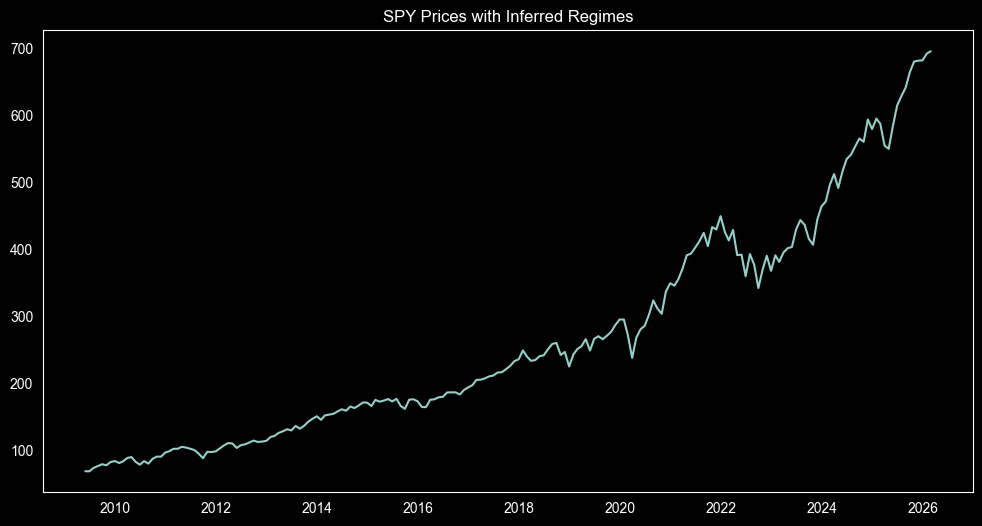

In [6]:
plt.figure(figsize= (12, 6))
plt.plot(spy_prices.loc[features.index])
plt.grid(False)
plt.title("SPY Prices with Inferred Regimes")
plt.savefig("spy_prices_with_regimes.png")

In [22]:
# Benchmark comparison
# we first align the dates
bench_data = asset_returns.loc[portfolio_returns.index]

spy_returns = bench_data["SPY"]
equal_weights = np.array([0.25,0.25,0.25,0.25])

equal_weight_returns = bench_data.values @ equal_weights
equal_weight_returns = pd.Series(equal_weight_returns.flatten(), index = bench_data.index)

# 60/40 portfolio
#### 60% Equities
#### 40% Bonds

In [47]:
weights_60_40 = np.array([0.6, 0.4])

sixty_forty_returns = bench_data[["SPY", "TLT"]].values @ weights_60_40
sixty_forty_returns = pd.Series(sixty_forty_returns.flatten(), index = bench_data.index)

#combining all strategies
strategies = pd.DataFrame({
    "Regime_Strategy": portfolio_returns,
    "SPY_BuyHold": spy_returns,
    "Equal_Weight": equal_weight_returns,
    "60/40": sixty_forty_returns
})

In [48]:
def performance_metrics(returns):

    ann_return = returns.mean()*12
    ann_vol = returns.std()* np.sqrt(12)

    sharpe = ann_return/ann_vol
    cumulative = (1 + returns).cumprod()
    max_dd = (cumulative/cumulative.cummax()-1).min()

    return pd.Series({
        "Annual Return": ann_return,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    })


In [50]:
metrics = strategies.apply(performance_metrics)
print(metrics)

               Regime_Strategy  SPY_BuyHold  Equal_Weight     60/40
Annual Return         0.063445     0.141199      0.067316  0.093433
Annual Vol            0.073270     0.141766      0.069132  0.096565
Sharpe                0.865903     0.996000      0.973734  0.967566
Max Drawdown         -0.153139    -0.254833     -0.169165 -0.275102


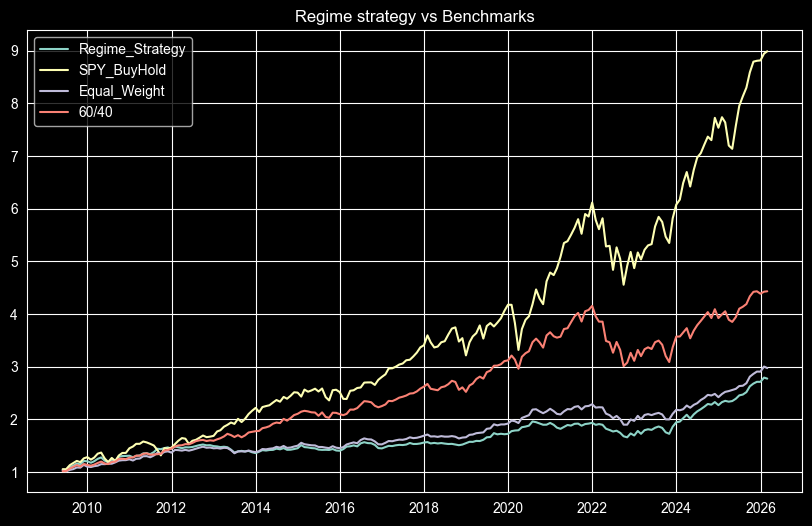

In [51]:
cumulative = (1 + strategies).cumprod()

plt.figure(figsize=(10,6))
plt.plot(cumulative)
plt.title("Regime strategy vs Benchmarks")
plt.legend(cumulative.columns)
plt.savefig("Regime strategy vs Benchmarks.png")

# Regime Overlay Plot

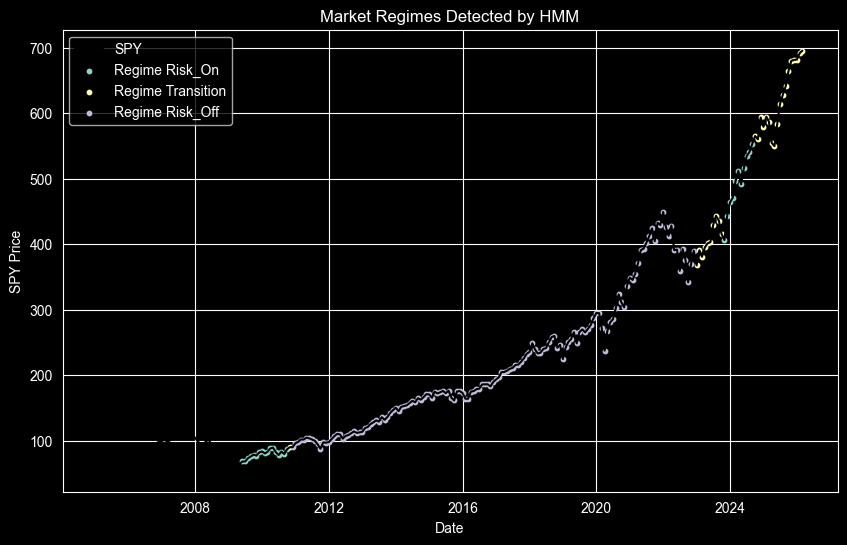

In [54]:
plt.figure(figsize = (10,6))
plt.plot(price_data_month["SPY"], label = "SPY", color = "black")

for reg in features["regime_label"].unique():

    regime_index = features[features["regime_label"] == reg].index
    plt.scatter(
        regime_index,
        price_data_month.loc[regime_index, "SPY"],
        label = f"Regime {reg}",
        s = 10
    )

    plt.title("Market Regimes Detected by HMM")
    plt.xlabel("Date")
    plt.ylabel("SPY Price")
    plt.legend()
    plt.grid(True)
    plt.savefig("MARKET REGIMES DETECTED BY HMM.png")

In [62]:
weights_over_time = []

for t in features.index:

    regime = features.loc[t, "regime_label"]
    w = np.array(weights[regime]).flatten()
    weights_over_time.append(w)

weights_over_time = pd.DataFrame(
    weights_over_time,
    index = features.index,
    columns = asset_returns.columns
)


# Computing Turn over

In [63]:
turnover = weights_over_time.diff().abs().sum(axis = 1)
turnover = turnover.fillna(0)

#Average Turnover
print(f"Average Turnover: {turnover.mean()}")

Average Turnover: 0.014851485148514854


# Transaction Costs

In [64]:
transaction_cost = 0.001
costs = turnover * transaction_cost

net_returns = portfolio_returns - costs
net_metrics = performance_metrics(net_returns)
print(net_metrics)

Annual Return    0.063267
Annual Vol       0.073285
Sharpe           0.863299
Max Drawdown    -0.153139
dtype: float64


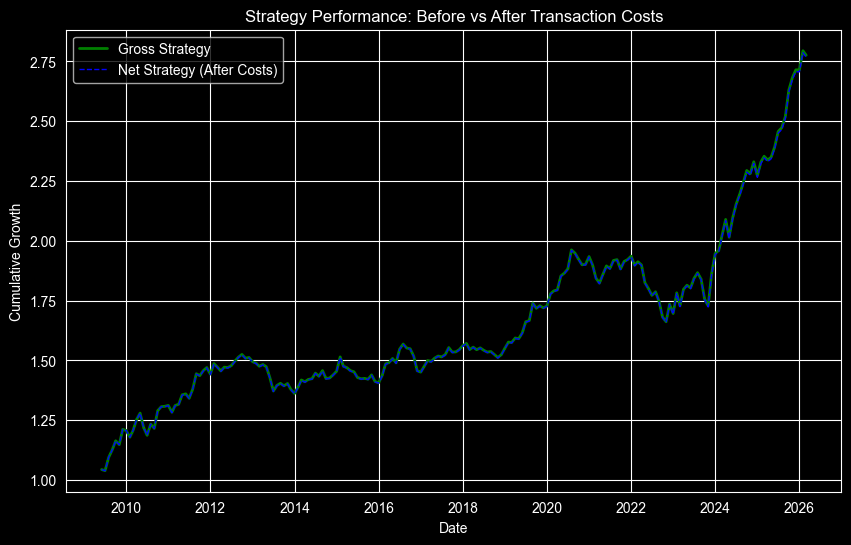

In [71]:
comparison = pd.DataFrame({
    "Gross Strategy": portfolio_returns,
    "Net Strategy": net_returns
})


plt.figure(figsize = (10,6))

plt.plot((1 + portfolio_returns).cumprod(),
         label="Gross Strategy",
         linewidth=2,
         color = "green")

plt.plot((1 + net_returns).cumprod(),
         linestyle="--",
         label="Net Strategy (After Costs)",
         linewidth=1,
         color  = "blue")

plt.title("Strategy Performance: Before vs After Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")

plt.legend()
plt.grid(True)
plt.savefig("Strategy Performance: Before vs After Transaction Costs.png")


# Drawdown Curve

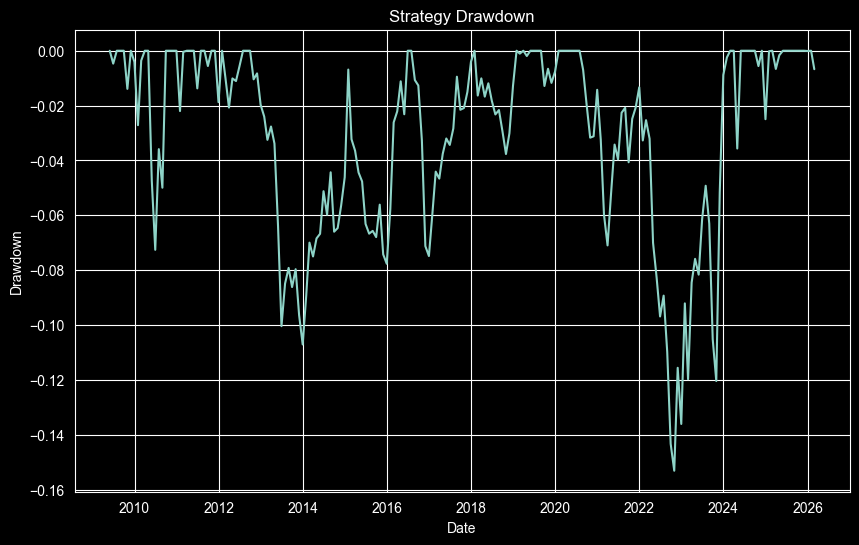

In [72]:
def compute_drawdown(returns):

    cumlate = (1 + returns).cumprod()
    peak = cumlate.cummax()
    dd = (cumlate - peak) / peak

    return dd

drawdowns = compute_drawdown(net_returns)
plt.figure(figsize=(10,6))
plt.plot(drawdowns)
plt.title("Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)

plt.savefig("Strategy Drawdown.png")

In [75]:
regime_sum = features.groupby("regime_label").agg({
    "Average_correlation": "mean",
    "max_eigenvalue": "mean"
})

print(regime_sum)

              Average_correlation  max_eigenvalue
regime_label                                     
Risk_Off                -0.006949        1.762875
Risk_On                  0.186589        1.678806
Transition               0.193228        1.845730


In [76]:
results = strategies.apply(performance_metrics)
print(results)

               Regime_Strategy  SPY_BuyHold  Equal_Weight     60/40
Annual Return         0.063445     0.141199      0.067316  0.093433
Annual Vol            0.073270     0.141766      0.069132  0.096565
Sharpe                0.865903     0.996000      0.973734  0.967566
Max Drawdown         -0.153139    -0.254833     -0.169165 -0.275102
